----
# Laboratorium 4 - Transmitancja i charakterystyki częstotliwościowe
----
Materiały dydaktyczne przeznaczone są wyłącznie dla studentów wydziału Informatyki i Telekomunikacji Politechniki Poznańskiej  

---- 
## 0. Zagadnienia do opanowania przed zajęciami
---- 
### 0.1. Zapoznanie z postawami biblioteki *sympy*
https://docs.sympy.org/latest/tutorial/index.html
### 0.2. Przydatne informacje:
Funkcje z biblioteki *sympy* potrzebne do zrealizowania ćwiczenia:  
`sympy.Symbol, sympy.I, sympy.re(), sympy.im(), sympy.Abs, sympy.arg`

Dokumentacja i opisy poszczególnych funkcji *sympy*:

- https://docs.sympy.org/latest/tutorial/gotchas.html#symbols  
- https://docs.sympy.org/latest/modules/utilities/lambdify.html
- https://docs.sympy.org/latest/modules/functions/elementary.html



---- 
## Transmitancje
---- 

$$ H1(s) = {{s} \over {5s + 1}} $$
$$ H2(s) = {{2} \over {s + 3}} $$
$$ H3(s) = {{s + 2} \over {s + 3}} $$
$$ H4(s) = {{s + 2} \over {s + 1}} $$
$$ H5(s) = {{2s + 3} \over {2s + 4}} $$
$$ H6(s) = {{1} \over {2s^2 + s + 1}} $$

In [46]:
%matplotlib inline
import sympy 
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
default_figsize=(12, 6)

----
## 1. Charakterystyka amplitudowa i fazowa układu - metoda analityczna
----
### Zadanie: Wyznacz i wyświetl matematyczną postać charakterystyki amplitudowej i fazowej dla układu o podanej transmitancji operatorowej.
Podpowiedź: użyj `sympy.I`, `sympy.re()`, `sympy.im()`

In [47]:
import sympy

# declare symbolic variable 'ω' (omega)
ω = sympy.Symbol('ω', real=True)
# declare symbolic variable 's'
s = 0 + sympy.I * ω

# Transmitancje układów
H1 = s / (5 * s + 1)
H2 = 2 / (s + 3)
H3 = (s + 2) / (s + 3)
H4 = (s + 2) / (s + 1)
H5 = (2 * s + 3) / (2 * s + 4)
H6 = 1 / (2 * s**2 + s + 1)

# Lista transmitancji
H_list = [H1, H2, H3, H4, H5, H6]

# Funkcja do wyznaczania części rzeczywistej i urojonej transmitancji
def ImRe(H):
    Im = sympy.im(H)
    Re = sympy.re(H)
    return Im, Re

# Funkcja do wyznaczania modułu i argumentu transmitancji
def amplitude_phase(H):
    amplitude = sympy.Abs(H)
    phase = sympy.arg(H)
    return amplitude, phase

# Wyznaczenie części rzeczywistej, urojonej, modułu i argumentu dla każdej transmitancji
for i in range(len(H_list)):
    Im, Re = ImRe(H_list[i])
    amplitude, phase = amplitude_phase(H_list[i])
    
    # Wydruk wyników
    print(f"Transmitancja H{i + 1}:")
    print(f"Re: {Re}, Im: {Im}")
    print(f"Moduł: {amplitude}, Argument: {phase}")
    print("\n")


Transmitancja H1:
Re: 5*ω**2/(25*ω**2 + 1), Im: ω/(25*ω**2 + 1)
Moduł: Abs(ω)/sqrt(25*ω**2 + 1), Argument: arg(I*ω/(5*I*ω + 1))


Transmitancja H2:
Re: 6/(ω**2 + 9), Im: -2*ω/(ω**2 + 9)
Moduł: 2/sqrt(ω**2 + 9), Argument: arg(1/(I*ω + 3))


Transmitancja H3:
Re: ω**2/(ω**2 + 9) + 6/(ω**2 + 9), Im: ω/(ω**2 + 9)
Moduł: sqrt(ω**2 + 4)/sqrt(ω**2 + 9), Argument: arg((I*ω + 2)/(I*ω + 3))


Transmitancja H4:
Re: ω**2/(ω**2 + 1) + 2/(ω**2 + 1), Im: -ω/(ω**2 + 1)
Moduł: sqrt(ω**2 + 4)/sqrt(ω**2 + 1), Argument: arg((I*ω + 2)/(I*ω + 1))


Transmitancja H5:
Re: 4*ω**2/(4*ω**2 + 16) + 12/(4*ω**2 + 16), Im: 2*ω/(4*ω**2 + 16)
Moduł: sqrt(4*ω**2 + 9)/sqrt(4*ω**2 + 16), Argument: arg((2*I*ω + 3)/(I*ω + 2))


Transmitancja H6:
Re: (1 - 2*ω**2)/(ω**2 + (1 - 2*ω**2)**2), Im: -ω/(ω**2 + (1 - 2*ω**2)**2)
Moduł: 1/sqrt(4*ω**4 - 3*ω**2 + 1), Argument: arg(1/(-2*ω**2 + I*ω + 1))




----
## 2. Charakterystyka amplitudowa i fazowa układu - metoda analityczna - wykres
----
### Zadanie: Sporządzić wykresy wyznaczonych wcześniej charakterystyk amplitudowej i fazowej
Okno wykresu podziel na dwie kolumny, w lewej umieść wykres charakterystyki amplitudowej a prawej wykres charakterystyki fazowej. Dodaj opisy i tytuły. Przyjmij wartości zmiennej 'w' z zakresu od $10^{-2}$ do $10^{2}$).  
Podpowiedź: użyj `numpy.logspace`, `sympy.lambdify`, `matplotlib.axes.Axes.loglog`, `matplotlib.axes.Axes.semilogx`

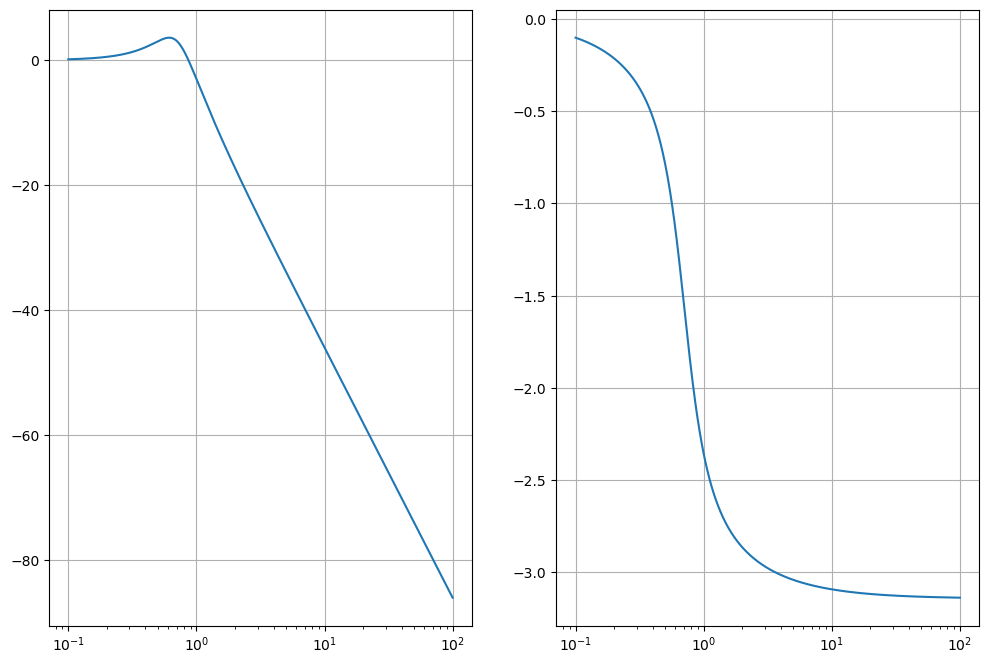

In [52]:
#wykres charakterystyki amplitudowej i charakterystyki fazowej

x = np.logspace(-1,2,1000)

def get_lamdified_functions(H_list):
    lamdified_amplitude = []
    lamdified_phase = []
    for H in H_list:
        lamdified_func = sympy.lambdify(ω, H)
        
        amplitude_func = lambda x: 20 * np.log10(np.abs(lamdified_func(x)))
        lamdified_amplitude.append(amplitude_func)

        phase_func = lambda x: np.angle(lamdified_func(x))
        lamdified_phase.append(phase_func)
        
    return lamdified_amplitude, lamdified_phase

lambdified_amplitude, lambdified_phase = get_lamdified_functions(H_list)
plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(x,lambdified_amplitude[5](x))
plt.xscale('log')
plt.subplot(1,2,2)
plt.grid()
plt.plot(x,lambdified_phase[5](x))
plt.xscale('log')





----
## 3. Charakterystyka amplitudowa i fazowa układu - metoda numeryczna
----
### Zadanie: Sporządzić wykresy charakterystyk amplitudowej i fazowej korzystając jedynie z biblioteki `numpy`
Okno wykresu podziel na dwie kolumny, w lewej umieść wykres charakterystyki amplitudowej a prawej wykres charakterystyki fazowej. Dodaj opisy i tytuły. Przyjmij wartości zmiennej 'w' z zakresu od $10^{-2}$ do $10^{2}$).  
Podpowiedź: $ H(s) = {{B(s)} \over {A(s)}} $
Podpowiedź: wylicz niezależnie wartości dla licznika i mianownika transmitancji  
Podpowiedź: użyj `numpy.logspace`, `numpy.poly1d`, `numpy.abs`, `numpy.angle`, `1j`

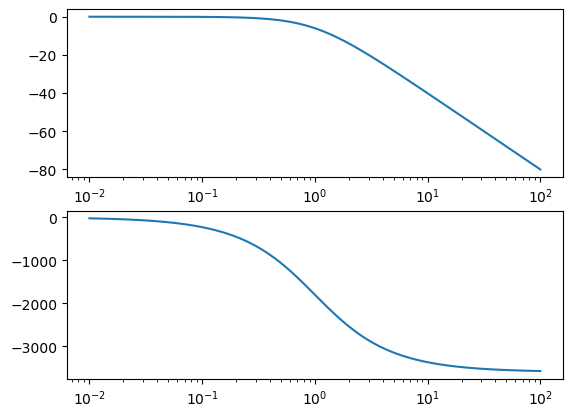

In [54]:
#kolejny wykres charakterystyki amplitudowej i fazowej
w = np.logspace(-2,2,400)
s = 1j * w

B = np.poly1d([1])
A = np.poly1d([1 ,2 , 1])

H = B(s)/A(s)

amplituda = np.abs(H)

faza = np.angle(H)

plt.subplot(2,1,1)
plt.semilogx(w, 20 * np.log10(amplituda))
plt.subplot(2,1,2)
plt.semilogx(w, 20 * np.degrees(faza))


----
## 4. Charakterystyka amplitudowa i fazowa układu - metoda numeryczna z użyciem funkcji `freqs` z biblioteki `scipy`
----
Okno wykresu podziel na dwie kolumny, w lewej umieść wykres charakterystyki amplitudowej a prawej wykres charakterystyki fazowej. Dodaj opisy i tytuły. Przyjmij wartości zmiennej 'w' z zakresu od $10^{-2}$ do $10^{2}$).  
Podpowiedź: użyj funkcji `scipy.signal.freqs` do wyliczenia wartości transmitancji. 

In [50]:
#jeszcze jeden wykres charakterystyki amplitudowej i fazowej



---- 
## 5. Charakterystyka amplitudowo-fazowa układu
---- 
### Zadanie: Wyznacz część rzeczywistą oraz część urojoną transmitancji układu. Sporządzić wykres charakterystyki amplitudowo-fazowej dla układu o zadanej transmitancji.
Przyjmij wartości zmiennej 'w' z zakresu od $10^{-2}$ do $10^{2}$).  
Podpowiedź: użyj `numpy.real()`, `numpy.imag()`

In [51]:
#dla odmiany wykres charakterystyki amplitudowo-fazowej

